# Generating consistent pSEOBNR LISA injections

This notebook generates time-domain `SEOBNRv5HM` modes (without any ringdown deviation), transforms them to the frequency domain, applies the full LISA A/E/T response, and saves mass-specific injection files for the recovery analysis.


## Importing the required packages


In [1]:
import os, sys
print(sys.executable)
print(os.environ.get("LD_PRELOAD"))

from pyseobnr.generate_waveform import GenerateWaveform, SupportedApproximants
print("pyseobnr import works")

/pbs/home/a/amahdi/.conda/envs/lisabeta/lib/python3.10/site-packages/pyseobnr/generate_waveform.py:6: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


/pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python
None
pyseobnr import works


In [2]:
import os
import h5py, json
import itertools
import copy
import warnings
from typing import get_args

import numpy as np
import scipy
from scipy.optimize import minimize
import matplotlib as mpl
import matplotlib.pyplot as plt


from tqdm import tqdm as tqdm

import astropy.cosmology
import astropy.units as u
from astropy.cosmology import Planck15 as cosmo
from pyseobnr.generate_waveform import GenerateWaveform, SupportedApproximants

# Using fonts that remain available without an external LaTeX installation.

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams["font.family"] = "DejaVu Serif"   # installed with Matplotlib


In [3]:
import lisabeta
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lvk.pyLVKresponse as pyLVKresponse
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils

import lal

In [4]:
%matplotlib inline

## Setting the plotting style


In [5]:
rc_params = {'backend': 'ps',
            'font.family': 'DejaVu Serif',
            'font.sans-serif': ['Bitstream Vera Sans'],
            'axes.unicode_minus':False,
            'text.usetex':False,
            'axes.grid':True,
            'grid.linestyle':':',
            'grid.linewidth':1.,
            'hist.bins':50,
            'axes.labelsize':16,
            'axes.titlesize':16,
            'xtick.labelsize':16,
            'ytick.labelsize':16,
            'legend.fontsize':16,
            'savefig.bbox':'tight',
            'savefig.transparent':True,
            'figure.dpi':100}
plt.rcParams.update(rc_params)

In [6]:
plt.rcParams.update({'figure.dpi':100})

In [7]:
# Using the same absolute directory in both the injection and recovery notebooks.
Syst_dir = "/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test"
os.makedirs(Syst_dir, exist_ok=True)
print("Syst_dir:", Syst_dir)
print("Syst_dir absolute:", os.path.abspath(Syst_dir))


Syst_dir: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test
Syst_dir absolute: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test


## Source and waveform parameters


In [8]:
# Generating pySEOBNR time-domain modes, applying the FFT, and then adding the lisabeta LISA/TDI response.

list_models_inj = ['SEOBNRv5HM']
list_models_temp = ['SEOBNRv5HMROM']
# Keeping the same six modes in the injection and recovery waveforms.
common_modes = [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]

'''
list_modes_inj = [common_modes]
list_modes_temp = [common_modes]

list_M = [1e4, 1e5, 1e6, 1e7, 1e8]
list_q = [2, 4, 8]
list_chi1 = [0., 0.5, 0.95]
list_chi2 = [0., 0.5, 0.95]
list_dfactor = np.power(2., np.arange(-2, 6))
list_inc = [np.pi/18, np.pi/3, np.pi/2-np.pi/18]
list_beta = [np.pi/18, np.pi/6, np.pi/2-np.pi/18]'''


'\nlist_modes_inj = [common_modes]\nlist_modes_temp = [common_modes]\n\nlist_M = [1e4, 1e5, 1e6, 1e7, 1e8]\nlist_q = [2, 4, 8]\nlist_chi1 = [0., 0.5, 0.95]\nlist_chi2 = [0., 0.5, 0.95]\nlist_dfactor = np.power(2., np.arange(-2, 6))\nlist_inc = [np.pi/18, np.pi/3, np.pi/2-np.pi/18]\nlist_beta = [np.pi/18, np.pi/6, np.pi/2-np.pi/18]'

In [9]:
z_base = 1.
dist_base = cosmo.luminosity_distance(z_base).value
dist_base

np.float64(6791.810623950696)

In [10]:
params_base = {
    'M': 1e6,
    'q': 4,
    'chi1': 0.5,
    'chi2': 0.5,
    'dist': 6791.810623950696,
    'inc': np.pi / 3,
    'phi': 0.7,
    'lambda': 1.0,
    'beta': np.pi / 6,
    'psi': 1.2,
    'Deltat': 0.0,
    'Lframe': True,
}

In [11]:
# Control of the starting frequency and sampling interval before applying FFT.


waveform_params_base = {
    "t0": 0.,

    # Setting the global analysis-frequency limits.
    # Choosing the TD starting frequency from `minf` and the requested observation time.
    "minf": 1e-5,
    "maxf": 0.2,

    # Setting the time-domain generation controls.
    # Increasing `T_obs` only after checking the waveform length and memory use.
    "T_obs": 60 * 86400,
    #"T_obs": pyconstants.YRSID_SI,
    #"T_obs": pyconstants.YRSID_SI/2,
    "max_td_samples": 2_000_000,

    # Choosing `deltaT` dynamically from the total mass and ringdown scale when it is left as `None`.
    "deltaT": None,

    # Selecting the aligned-spin pySEOBNR model.
    "approximant": "SEOBNRv5HM",
    "modes": common_modes,

    # Setting the LISA/TDI response options.
    "timetomerger_max": 2.0,
    "DeltalnMf_max": 0.01,
    "TDIrescaled": True,
    "TDI": "TDIAET",
    "LISAnoise": pyLISAnoise.LISAnoiseSciRDv1,

    # Leaving the optional pySEOBNR deviation dictionaries inactive for the GR injection.
    # "domega_dict": {},
    # "dtau_dict": {},
    # "dA_dict": {},
    # "dw_dict": {},
}
waveform_params_base['LISAnoise']['WDbackground'] = True
waveform_params_base['LISAnoise']['WDduration'] = 4.


# Applying the physical orbital phase only through the LISA response and avoiding double counting in `phi_ref`.
waveform_params_base["pseob_phi_ref"] = 0.0

# Keep the FTI-style parameters at zero for the GR injection while recording them in the parameter files. 
FTI_ZERO_PARAMS = [
    "fti_dchiMinus2v", "fti_dchi0v", "fti_dchi1v", "fti_dchi2v",
    "fti_dchi3v", "fti_dchi4v", "fti_dchi5lv", "fti_dchi6v",
    "fti_dchi6lv", "fti_dchi7v", "fti_dkappa_S", "fti_dxi0v",
]

# Even if not mentioned,FTI params are zero by default

print('pySEOBNR supported approximants:', get_args(SupportedApproximants))


pySEOBNR supported approximants: ('SEOBNRv5HM', 'SEOBNRv5PHM', 'SEOBNRv5EHM')


## Building the pSEOBNR signal


## Generating the injection catalog


### Defining the waveform helper functions


In [12]:
# time-domain downsampling rule based on the spline-interpolation error criterion.

def Deltat_insp(nu, t, acc=1e-4, tc=0.):
    Lambda = 8./3 * np.pi**(5./12) * (acc * nu)**(1./4)
    return 8*Lambda/3 * 5./(256*nu) * (256*nu/5 * (tc-t))**(27/32.)

def downsamplemask_arr_byfunc(x, func_dx):
    mask_ds = np.zeros_like(x, dtype=bool)
    i = 0
    while (i < len(x)-1):
        mask_ds[i] = True
        dx = x[i+1] - x[i]
        dx_func = func_dx(x[i])
        i += int(dx_func/dx)
    mask_ds[len(x)-1] = True
    return mask_ds


### Keeping the injection and recovery conventions consistent

We use only one directory and one set of waveform conventions throughout the injection and recovery calculations:

1. Saving all injection products under `/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data`.
2. Applying the physical orbital phase `phi` only through the LISA response while keeping the pySEOBNR reference phase at zero.
3. Applying the frequency-domain time shift as `phase += 2π f Deltat` and shifting `tf` by the same `Deltat`.
4. Saving `TDIA`, `TDIE`, and `TDIT` so the residual, mismatch, beta, and Fisher calculations use the same channel set.
5. Keeping the FTI parameters at zero and inactive for this GR consistency (null test) calculation.


In [13]:
# convert the pySEOBNR time-domain modes to frequency-domain modes.

def mode_key_variants(lm):
    l, m = lm
    return [lm, (l, m), f"{l},{m}", f"{l}{m}", f"h{l}{m}"]


def get_mode_from_dict(hlm, lm):
    for key in mode_key_variants(lm):
        if key in hlm:
            return hlm[key]
    raise KeyError(f"Mode {lm} not found. Available keys: {list(hlm.keys())[:20]}")


def choose_f_start_from_Tobs(m1, m2, waveform_params):
    f_min_user = waveform_params.get("minf", 1e-5)
    T_obs = waveform_params.get("T_obs", 3 * 86400)
    f_from_T = pytools.funcNewtonianfoft(m1, m2, T_obs)
    return max(f_min_user, f_from_T), T_obs, f_from_T


def choose_deltaT(M, waveform_params):
    maxf = float(waveform_params.get("maxf", 0.2))
    user_deltaT = waveform_params.get("deltaT", None)

    M_seconds = M * pyconstants.MTSUN_SI
    f_rd_est = 0.08 / M_seconds

    delta_from_maxf = 1.0 / (4.0 * maxf)
    delta_from_ringdown = 1.0 / (8.0 * f_rd_est)
    auto_deltaT = min(delta_from_maxf, delta_from_ringdown)

    if user_deltaT is None:
        return auto_deltaT, f_rd_est

    return min(float(user_deltaT), auto_deltaT), f_rd_est


def generate_pseob_td(params, modes=None, waveform_params=None, verbose=True):
    """
    Generating the pySEOBNR time-domain h_lm modes for the given source parameters.
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    chi1 = float(params.get("chi1", 0.0))
    chi2 = float(params.get("chi2", 0.0))

    distance = float(params.get("dist", 1.0))
    inclination = float(params.get("inc", 0.0))
    phi_ref = float(waveform_params.get("pseob_phi_ref", 0.0))

    f_min, T_obs, f_from_T = choose_f_start_from_Tobs(m1, m2, waveform_params)
    f_max = float(waveform_params.get("maxf", 0.2))

    deltaT, f_rd_est = choose_deltaT(M, waveform_params)

    approx = waveform_params.get("approximant", "SEOBNRv5HM")

    params_pseob = {
        "mass1": m1,
        "mass2": m2,
        "spin1x": 0.0,
        "spin1y": 0.0,
        "spin1z": chi1,
        "spin2x": 0.0,
        "spin2y": 0.0,
        "spin2z": chi2,
        "distance": distance,
        "inclination": inclination,
        "phi_ref": phi_ref,
        "f22_start": f_min,
        "f_ref": f_min,
        "f_max": f_max,
        "deltaT": deltaT,
        "approximant": approx,
        "mode_array": modes,
    }

    for key in ["domega_dict", "dtau_dict", "dA_dict", "dw_dict", "lmax_nyquist"]:
        if key in waveform_params:
            params_pseob[key] = waveform_params[key]

    if verbose:
        print(
            f"pySEOBNR TD: M={M:.3e}, q={q:.3f}, "
            f"chi1={chi1:.3f}, chi2={chi2:.3f}, "
            f"f22_start={f_min:.3e} Hz, f_from_T={f_from_T:.3e} Hz, "
            f"f_RD_est={f_rd_est:.3e} Hz, f_max={f_max:.3e} Hz, "
            f"deltaT={deltaT:.3e} s, phi_ref={phi_ref:.6g}"
        )

    times, hlm_raw = GenerateWaveform(params_pseob).generate_td_modes()
    times = np.asarray(times)

    hlm_out = {}

    for lm in modes:
        try:
            hlm_out[lm] = np.asarray(get_mode_from_dict(hlm_raw, lm), dtype=complex)
        except KeyError:
            warnings.warn(f"Requested mode {lm} was not returned by pySEOBNR. Skipping.")

    if not hlm_out:
        raise RuntimeError(f"No requested modes returned. Available keys: {list(hlm_raw.keys())[:20]}")

    return times, hlm_out


def generate_pseob_fft(
    params,
    modes=None,
    waveform_params=None,
    verbose=True,
):
    """
    Generating frequency-domain pSEOB modes by tapering and zero-padding the time series, applying the FFT, interpolating onto a geometric frequency grid, and calculating tf = dphase/(2πdf).
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    Deltat_w_end = 40.0
    Deltat_w_beg = 10000.0

    minf = float(waveform_params.get("minf", 1e-5))
    maxf = float(waveform_params.get("maxf", 0.2))
    n_freq = int(waveform_params.get("n_freq", 10000))

    # Generating the time-domain pSEOB waveform.

    t, h = generate_pseob_td(
        params,
        modes=modes,
        waveform_params=waveform_params,
        verbose=verbose,
    )

    # Check that the time grid is uniform before applying the FFT.
    dt_arr = np.diff(t)

    if len(dt_arr) == 0:
        raise ValueError("The time-domain waveform has fewer than two samples.")

    if not np.allclose(dt_arr, dt_arr[0], rtol=1e-5, atol=0):
        raise ValueError(
            "pySEOBNR returned a non-uniform time grid. "
            "This original-style FFT cell assumes uniform sampling."
        )

    # Apply the Planck taper, zero padding, and FFT respectively.

    w = pytools.window_planck_vec(t, t[0], t[-1], Deltat_w_beg, Deltat_w_end)

    hlm_fft = {}

    for lm in modes:
        if lm not in h:
            warnings.warn(f"Mode {lm} missing from pSEOB TD output. Skipping.")
            continue

        hlm_ts = np.array([
            t,
            w * np.real(h[lm]),
            w * np.imag(h[lm])
        ]).T

        hlm_ts = pytools.zeropad(hlm_ts, extend=1)

        # Using the original positive-frequency FFT helper.
        hlm_fs = pytools.fft_positivef(hlm_ts)

        freq = hlm_fs[:, 0]
        hf = hlm_fs[:, 1] + 1j * hlm_fs[:, 2]

        amp = np.abs(hf)
        phase = np.unwrap(np.angle(hf))

        hlm_fft[lm] = {}
        hlm_fft[lm]["freq"] = freq
        hlm_fft[lm]["amp"] = amp
        hlm_fft[lm]["phase"] = phase

    if not hlm_fft:
        raise RuntimeError("No modes were converted to frequency domain.")

    # Interpolate the mode amplitude and phase onto a clean geometric frequency grid.

    f_low_available = max([hlm_fft[lm]["freq"][0] for lm in hlm_fft])
    f_high_available = min([hlm_fft[lm]["freq"][-1] for lm in hlm_fft])

    if minf < f_low_available:
        raise ValueError(
            f"minf={minf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common lower limit is {f_low_available:.6e}."
        )

    if maxf > f_high_available:
        raise ValueError(
            f"maxf={maxf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common upper limit is {f_high_available:.6e}."
        )


    M = float(params["M"])
    q = float(params["q"])
    
    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)
    
    f_min, T_obs, f_from_T = choose_f_start_from_Tobs(
    m1, m2, waveform_params
    )
    
    freq = np.geomspace(minf, maxf, n_freq)
    
    hlm_fd = {}

    for lm in modes:
        if lm not in hlm_fft:
            continue

        spline_amp_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["amp"]
        )

        spline_phase_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["phase"]
        )

        mask_fft = (
            (hlm_fft[lm]["freq"][0] <= freq)
            & (freq <= hlm_fft[lm]["freq"][-1])
        )

        amp = np.zeros_like(freq)
        phase = np.zeros_like(freq)

        amp[mask_fft] = spline_amp_fft(freq[mask_fft])
        phase[mask_fft] = spline_phase_fft(freq[mask_fft])

        hlm_fd[lm] = {}
        hlm_fd[lm]["freq"] = freq.copy()
        hlm_fd[lm]["amp"] = amp.copy()
        hlm_fd[lm]["phase"] = phase.copy()

        hlm_fd[lm]["tf"] = (
            1.0 / (2.0 * np.pi)
            * pytools.spline(
                hlm_fd[lm]["freq"],
                hlm_fd[lm]["phase"]
            )(hlm_fd[lm]["freq"], 1)
        )

        hlm_fd[lm]["h"] = (
            hlm_fd[lm]["amp"]
            * np.exp(1j * hlm_fd[lm]["phase"])
        )

    if verbose:
        print("pSEOB FD construction:")
        print("  modes kept =", list(hlm_fd.keys()))
        print("  freq range =", freq[0], freq[-1])
        print("  n_freq     =", len(freq))

    return hlm_fd


In [14]:
# Building the lisabeta LISA/TDI response from the pSEOB frequency-domain modes.

def build_wftdi_from_hlm_fd(
    params,
    hlm_fd,
    modes,
    t0=0.0,
    TDI="TDIAET",
    TDIrescaled=True,
):
    """
    Building the `wftdi` structure expected by lisabeta and attaching the LISA/TDI response to the previously generated pSEOB frequency-domain modes.
    """

    params_local = copy.deepcopy(params)

    if params_local.get("Lframe", False):
        params_local = lisatools.convert_Lframe_to_SSBframe(params_local, t0=t0)
        params_local["Lframe"] = False

    Deltat = params_local["Deltat"]
    inc = params_local["inc"]
    phi = params_local["phi"]
    lambd = params_local["lambda"]
    beta = params_local["beta"]
    psi = params_local["psi"]

    wftdi = {"modes": []}

    for lm in modes:
        if lm not in hlm_fd:
            warnings.warn(f"Mode {lm} missing from hlm_fd. Skipping.")
            continue

        freq = np.asarray(hlm_fd[lm]["freq"])
        amp = np.asarray(hlm_fd[lm]["amp"])
        phase = np.asarray(hlm_fd[lm]["phase"])
        tf = np.asarray(hlm_fd[lm]["tf"])

        good = (
            np.isfinite(freq)
            & np.isfinite(amp)
            & np.isfinite(phase)
            & np.isfinite(tf)
            & (freq > 0)
        )

        freq = freq[good]
        amp = amp[good]
        phase = phase[good]
        tf = tf[good]

        if len(freq) < 10:
            warnings.warn(f"Mode {lm} has too few valid FD samples. Skipping.")
            continue

        wftdi["modes"].append(lm)

        # Applying the same time-shift convention to the phase and tf = (1/2π) dphase/df.
        wftdi[lm] = {}
        wftdi[lm]["freq"] = freq
        wftdi[lm]["amp"] = amp
        wftdi[lm]["phase"] = phase + (2.0 * np.pi) * freq * Deltat
        wftdi[lm]["tf"] = tf + Deltat

        tdiClass = pyresponse.LISAFDresponseTDI3Chan(
            wftdi[lm]["freq"],
            wftdi[lm]["tf"],
            t0,
            lm[0],
            lm[1],
            inc,
            phi,
            lambd,
            beta,
            psi,
            TDI=TDI,
            TDIrescaled=TDIrescaled,
        )

        (
            wftdi[lm]["phaseRdelay"],
            wftdi[lm]["transferL1"],
            wftdi[lm]["transferL2"],
            wftdi[lm]["transferL3"],
        ) = tdiClass.get_response()

    if not wftdi["modes"]:
        raise RuntimeError("No modes were available for TDI response construction.")

    return params_local, wftdi


def make_frequency_grid_from_hlm_fd(
    params,
    hlm_fd,
    waveform_params=None,
    Deltalnf=5e-4,
    refine=1,
):
    """
    Building the final response grid from the common frequency support of the generated pSEOB modes and the Newtonian observation-time limit.
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    modes = waveform_params.get("modes", list(hlm_fd.keys()))

    f_lows = []
    f_highs = []

    for lm in modes:
        if lm not in hlm_fd:
            continue

        f = np.asarray(hlm_fd[lm]["freq"])
        f = f[np.isfinite(f) & (f > 0)]

        if len(f) < 2:
            continue

        f_lows.append(f[0])
        f_highs.append(f[-1])

    if len(f_lows) == 0:
        raise RuntimeError("Cannot build frequency grid: no valid mode frequency arrays.")

    fLow = np.fmax(max(f_lows), waveform_params.get("minf", 1e-5))
    fHigh = np.fmin(min(f_highs), waveform_params.get("maxf", 0.2))
    
    # Recomputing the physical starting frequency locally for this response grid.
    f_min_phys, T_obs_start, f_from_T = choose_f_start_from_Tobs(
        m1, m2, waveform_params
    )
    
    fLow = waveform_params["minf"]
    
    T_est = pytools.funcNewtoniantoff(m1, m2, fLow)
    T = np.fmin(pyconstants.YRSID_SI, np.fmax(30.0 * 86400.0, T_est))

    fLow = np.fmax(fLow, pytools.funcNewtonianfoft(m1, m2, T))

    if not (fLow < fHigh):
        raise ValueError(f"Bad response frequency range: fLow={fLow}, fHigh={fHigh}")

    freq_nyq_log = pytools.composite_nyquist_log_freq_grid(
        fLow,
        fHigh,
        m1,
        m2,
        Deltalnf=Deltalnf,
        refine=refine,
    )

    return freq_nyq_log


## Checking selected corners of the parameter space


In [15]:
n_corners = 4

q_corners = np.array([1.1, 1.1, 8., 8.])
chi1_corners = np.array([0.8, -0.8, 0.8, -0.8])
chi2_corners = np.array([0.8, -0.8, 0.8, -0.8])

In [16]:
from lisabeta.lisa import lisa

print(lisa.list_approximants_smbh)

['IMRPhenomD', 'IMRPhenomHM', 'IMRPhenomX', 'IMRPhenomXHM', 'EOBNRv2HMROM', 'SEOBNRv4HMROM', 'SEOBNRv5HMROM', 'TaylorF2Ecc']


In [17]:
modes = waveform_params_base["modes"]

hlm_fd_pseob_corner = {}

for i in tqdm(range(n_corners)):
    params = copy.deepcopy(params_base)
    params["q"] = q_corners[i]
    params["chi1"] = chi1_corners[i]
    params["chi2"] = chi2_corners[i]

    hlm_fd_pseob_corner[i] = generate_pseob_fft(
        params,
        modes=modes,
        waveform_params=waveform_params_base,
        verbose=True,
    )

  0%|          | 0/4 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+06, q=1.100, chi1=0.800, chi2=0.800, f22_start=1.372e-04 Hz, f_from_T=1.372e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 25%|██▌       | 1/4 [00:32<01:36, 32.08s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=1.100, chi1=-0.800, chi2=-0.800, f22_start=1.372e-04 Hz, f_from_T=1.372e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 50%|█████     | 2/4 [00:47<00:44, 22.23s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=8.000, chi1=0.800, chi2=0.800, f22_start=1.941e-04 Hz, f_from_T=1.941e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 75%|███████▌  | 3/4 [01:16<00:25, 25.41s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=8.000, chi1=-0.800, chi2=-0.800, f22_start=1.941e-04 Hz, f_from_T=1.941e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


100%|██████████| 4/4 [01:34<00:00, 23.71s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


In [18]:
hlm_fd_pseob_corner[0][(2,2)].keys()


dict_keys(['freq', 'amp', 'phase', 'tf', 'h'])

In [19]:
modes

[(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]

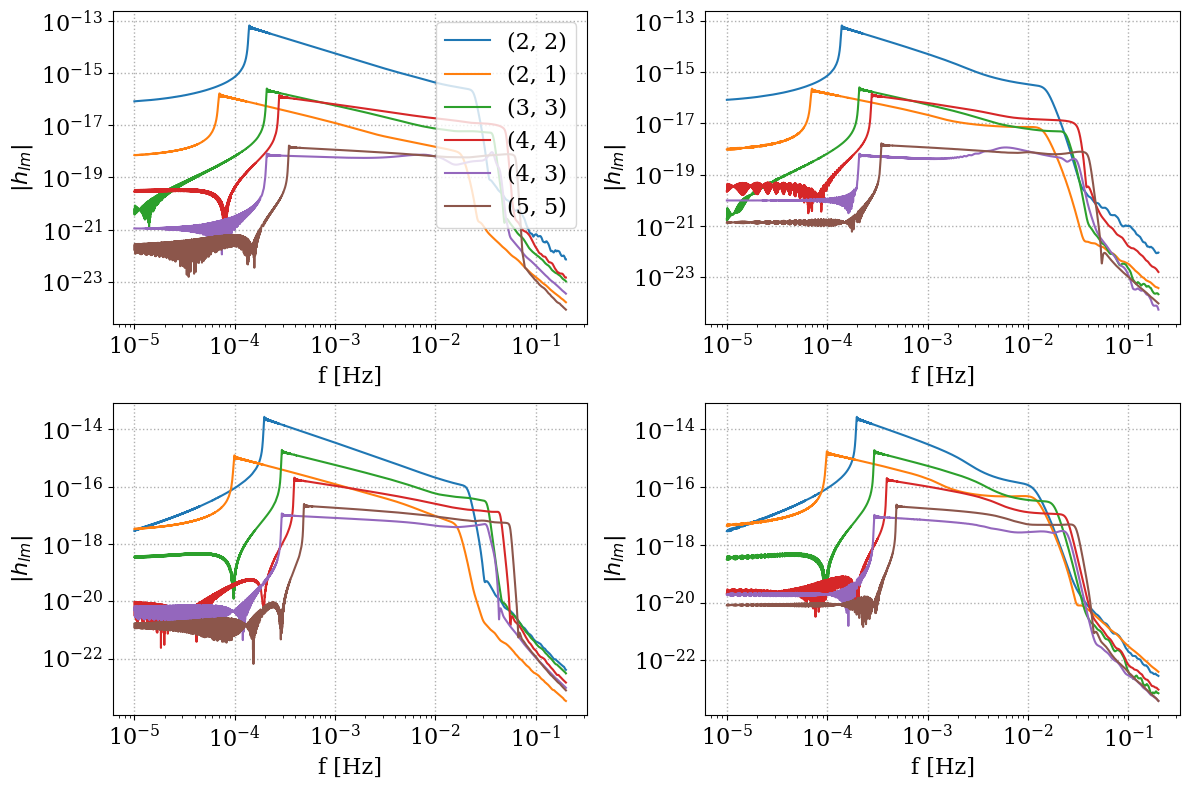

In [20]:
# q, chi1, chi2 [0,3]
fig, axs = plt.subplots(2, 2, figsize=[12, 8])

for i_corner in range(4):
    row, col = divmod(i_corner, 2)
    ax = axs[row][col]
    for lm in modes:
        ax.loglog(hlm_fd_pseob_corner[i_corner][lm]['freq'],
                  hlm_fd_pseob_corner[i_corner][lm]['amp'],
                  label=str(lm) if i_corner == 0 else None)
    if i_corner == 0:
        ax.legend(loc='best')
    ax.set_xlabel('f [Hz]')
    ax.set_ylabel(r'$|h_{lm}|$')

plt.tight_layout()


## Preparing the intrinsic-parameter catalog


In [21]:
np.random.seed(1)

N = 1

# Using one fixed intrinsic-parameter point for the present consistency check; using the ranges below when drawing a random catalog.
# q = np.random.uniform(1.1, 8.0, size=N)
# chi1 = np.random.uniform(-0.8, 0.8, size=N)
# chi2 = np.random.uniform(-0.8, 0.8, size=N)
q = 4 * np.ones(N)
chi1 = 0.5 * np.ones(N)
chi2 = 0.5 * np.ones(N)

geom_file = os.path.join(Syst_dir, 'geomparams_injection_set.h5')
with h5py.File(geom_file, 'w') as f:
    f.create_dataset('q', data=q)
    f.create_dataset('chi1', data=chi1)
    f.create_dataset('chi2', data=chi2)

print('Saved:', geom_file)


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/geomparams_injection_set.h5


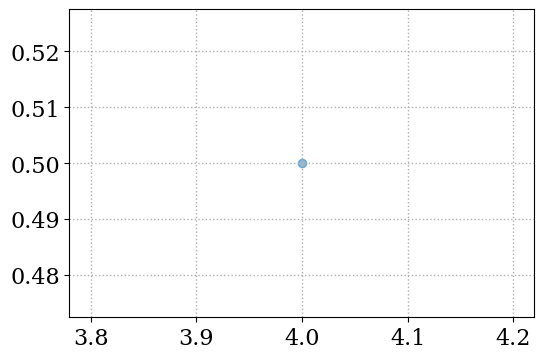

In [22]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.scatter(q, chi1, alpha=0.5)

In [23]:
# Marking the direct pSEOB generation as successful without loading separate NRSur hybrid files.
success = np.ones(N, dtype=bool)


In [24]:
q, chi1, chi2

(array([4.]), array([0.5]), array([0.5]))

In [25]:
np.arange(N)[~success]

array([], dtype=int64)

In [26]:
# i_failures = [38,133]

In [27]:
[(q[i], chi1[i], chi2[i]) for i in np.arange(N)[~success]]

[]

## Preparing the mass and orientation catalogs


In [28]:
injection_set = {}
geom_file = os.path.join(Syst_dir, 'geomparams_injection_set.h5')

with h5py.File(geom_file, 'r') as hf:
    injection_set['q'] = hf['q'][:]
    injection_set['chi1'] = hf['chi1'][:]
    injection_set['chi2'] = hf['chi2'][:]

print('Loaded:', geom_file)


Loaded: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/geomparams_injection_set.h5


In [29]:
listM = [1e5, 1e6, 1e7]
listM_str = ['M1e5', 'M1e6', 'M1e7']

Lframe = True

np.random.seed(1)

dist = dist_base * np.ones(N, dtype=float)
Deltat = np.zeros(N, dtype=float)
inc = np.random.uniform(low=np.pi/3, high=np.pi/3, size=N)
phi = np.random.uniform(low=0.7, high=0.7, size=N)
lambda_ = np.random.uniform(low=1, high=1, size=N)
beta = np.random.uniform(low=np.pi/6, high=np.pi/6, size=N)
psi = np.random.uniform(low=1.2, high=1.2, size=N)

for iM in range(3):
    M = listM[iM]
    params_file = os.path.join(Syst_dir, 'params_injection_set_' + listM_str[iM] + '.h5')
    with h5py.File(params_file, 'w') as hf:
        hf.create_dataset('M', data=M * np.ones(N, dtype=float))
        hf.create_dataset('q', data=injection_set['q'])
        hf.create_dataset('chi1', data=injection_set['chi1'])
        hf.create_dataset('chi2', data=injection_set['chi2'])
        hf.create_dataset('Deltat', data=Deltat)
        hf.create_dataset('dist', data=dist)
        hf.create_dataset('inc', data=inc)
        hf.create_dataset('phi', data=phi)
        hf.create_dataset('lambda', data=lambda_)
        hf.create_dataset('beta', data=beta)
        hf.create_dataset('psi', data=psi)
        hf.create_dataset('Lframe', data=np.array([int(Lframe)]))
        for p in FTI_ZERO_PARAMS:
            hf.create_dataset(p, data=np.zeros(N, dtype=float))
    print('Saved:', params_file)


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e5.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e6.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e7.h5


## Generating and saving the LISA injections


In [30]:
# Generating the pSEOB modes directly.
data_dir = Syst_dir
listM = [1e5, 1e6, 1e7]
listM_str = ['M1e5', 'M1e6', 'M1e7']
N = 1
modes = [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]


In [31]:
'''# Retaining optional reference frequencies for diagnostics without using them in the pSEOB FFT.
fdamp = {
    (2,2): 0.14,
    (2,1): 0.11,
    (3,3): 0.18,
    (3,2): 0.14,
    (4,4): 0.22,
    #(4,3): 0.2,
    #(5,5): 0.3,
}
'''

'# Retaining optional reference frequencies for diagnostics without using them in the pSEOB FFT.\nfdamp = {\n    (2,2): 0.14,\n    (2,1): 0.11,\n    (3,3): 0.18,\n    (3,2): 0.14,\n    (4,4): 0.22,\n    #(4,3): 0.2,\n    #(5,5): 0.3,\n}\n'

In [32]:
# Generate the pySEOBNR injection signal and saving `freq`, `TDIA`, `TDIE`, and `TDIT` for the recovery notebook.

inj_dir = Syst_dir

modes_out = waveform_params_base["modes"]
modes = waveform_params_base["modes"]

t0 = waveform_params_base['t0']
TDI = waveform_params_base.get('TDI', 'TDIAET')
TDIrescaled = waveform_params_base.get('TDIrescaled', True)

list_params = ['M', 'q', 'chi1', 'chi2', 'Deltat', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']

for iM in range(3):
    params_file = os.path.join(Syst_dir, 'params_injection_set_' + listM_str[iM] + '.h5')
    injection_set_params = {}

    print('Reading:', params_file)
    with h5py.File(params_file, 'r') as hf:
        for p in list_params:
            injection_set_params[p] = hf[p][:]
        injection_set_params['Lframe'] = bool(hf['Lframe'][:][0])

    out_dir = os.path.join(inj_dir, listM_str[iM])
    os.makedirs(out_dir, exist_ok=True)
    print('Writing:', out_dir)

    for i in tqdm(range(N)):
        params = {p: injection_set_params[p][i] for p in list_params}
        params['Lframe'] = injection_set_params['Lframe']

        # Generating the pySEOBNR time-domain modes and applying the FFT.
        hlm_fd = generate_pseob_fft(
            params,
            modes=modes,
            waveform_params=waveform_params_base,
            verbose=True,
        )

        # Saving the raw frequency-domain h_lm modes.
        hlm_out_file = os.path.join(out_dir, 'hlm_fd_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(hlm_out_file, 'w') as hf:
            for lm, data in hlm_fd.items():
                g = hf.create_group('h' + str(lm[0]) + str(lm[1]))
                for k in ['freq', 'h', 'amp', 'phase', 'tf']:
                    g.create_dataset(k, data=data[k])

        # Building the response-ready `wftdi` dictionary and attaching the LISA/TDI response.
        params_ssb, wftdi = build_wftdi_from_hlm_fd(
            params,
            hlm_fd,
            modes=modes,
            t0=t0,
            TDI=TDI,
            TDIrescaled=TDIrescaled,
        )

        # Building the final response grid and evaluating the complex TDI series.
        freq_nyq_log = make_frequency_grid_from_hlm_fd(
            params_ssb,
            hlm_fd,
            waveform_params=waveform_params_base,
            Deltalnf=5e-4,
            refine=1,
        )

        tdi = lisa.GetCAmpPhaseTDI(wftdi)
        tdi_fs = lisa.EvaluateTDIFreqseries(tdi, freq_nyq_log)

        data_out = {
            'freq': freq_nyq_log,
            'TDIA': np.zeros_like(freq_nyq_log, dtype=complex),
            'TDIE': np.zeros_like(freq_nyq_log, dtype=complex),
            'TDIT': np.zeros_like(freq_nyq_log, dtype=complex),
        }

        for lm in modes_out:
            if lm in tdi_fs:
                data_out['TDIA'] += tdi_fs[lm]['chan1']
                data_out['TDIE'] += tdi_fs[lm]['chan2']
                data_out['TDIT'] += tdi_fs[lm]['chan3']

        data_out_file = os.path.join(out_dir, 'data_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(data_out_file, 'w') as hf:
            hf.create_dataset('freq', data=data_out['freq'])
            hf.create_dataset('TDIA', data=data_out['TDIA'])
            hf.create_dataset('TDIE', data=data_out['TDIE'])
            hf.create_dataset('TDIT', data=data_out['TDIT'])

        # Saving the mode-by-mode TDI contributions.
        datalm_out_file = os.path.join(out_dir, 'datalm_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(datalm_out_file, 'w') as hf:
            for lm in modes:
                if lm in tdi_fs:
                    g = hf.create_group('h' + str(lm[0]) + str(lm[1]))
                    g.create_dataset('freq', data=freq_nyq_log)
                    g.create_dataset('TDIA', data=tdi_fs[lm]['chan1'])
                    g.create_dataset('TDIE', data=tdi_fs[lm]['chan2'])
                    g.create_dataset('TDIT', data=tdi_fs[lm]['chan3'])

        print('Saved:', hlm_out_file)
        print('Saved:', data_out_file)
        print('Saved:', datalm_out_file)



Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e5.h5
Writing: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e5


  0%|          | 0/1 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+05, q=4.000, chi1=0.500, chi2=0.500, f22_start=6.832e-04 Hz, f_from_T=6.832e-04 Hz, f_RD_est=1.624e-01 Hz, f_max=2.000e-01 Hz, deltaT=7.696e-01 s, phi_ref=0
pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


100%|██████████| 1/1 [00:29<00:00, 29.83s/it]


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e5/hlm_fd_pseob_M1e5_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e5/data_pseob_M1e5_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e5/datalm_pseob_M1e5_id_0.h5
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e6.h5
Writing: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e6


...

Writing: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e7


  0%|          | 0/1 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+07, q=4.000, chi1=0.500, chi2=0.500, f22_start=3.842e-05 Hz, f_from_T=3.842e-05 Hz, f_RD_est=1.624e-03 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0
pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


100%|██████████| 1/1 [00:27<00:00, 27.98s/it]

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e7/hlm_fd_pseob_M1e7_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e7/data_pseob_M1e7_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e7/datalm_pseob_M1e7_id_0.h5


Groups: ['h21', 'h22', 'h33', 'h43', 'h44', 'h55']


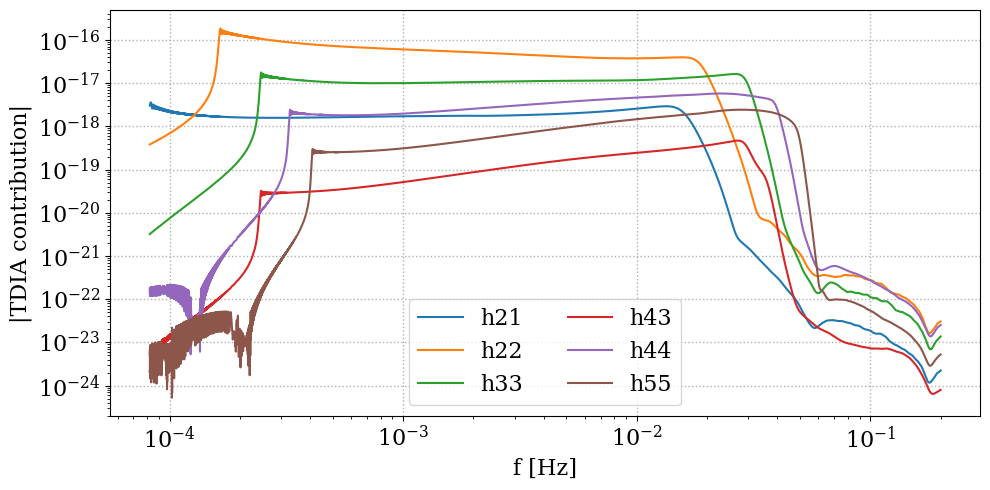

In [33]:
datalm_file = os.path.join(
    Syst_dir,
    "M1e6",
    "datalm_pseob_M1e6_id_0.h5"
)

with h5py.File(datalm_file, "r") as hf:
    print("Groups:", list(hf.keys()))

    plt.figure(figsize=(10, 5))

    for group in hf.keys():
        f = hf[group]["freq"][:]
        A = hf[group]["TDIA"][:]
        plt.loglog(f, np.abs(A), label=group)

    plt.xlabel("f [Hz]")
    plt.ylabel("|TDIA contribution|")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [34]:
wftdi.keys()


dict_keys(['modes', (2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)])

pySEOBNR TD: M=1.000e+06, q=4.000, chi1=0.500, chi2=0.500, f22_start=1.620e-04 Hz, f_from_T=1.620e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0
pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


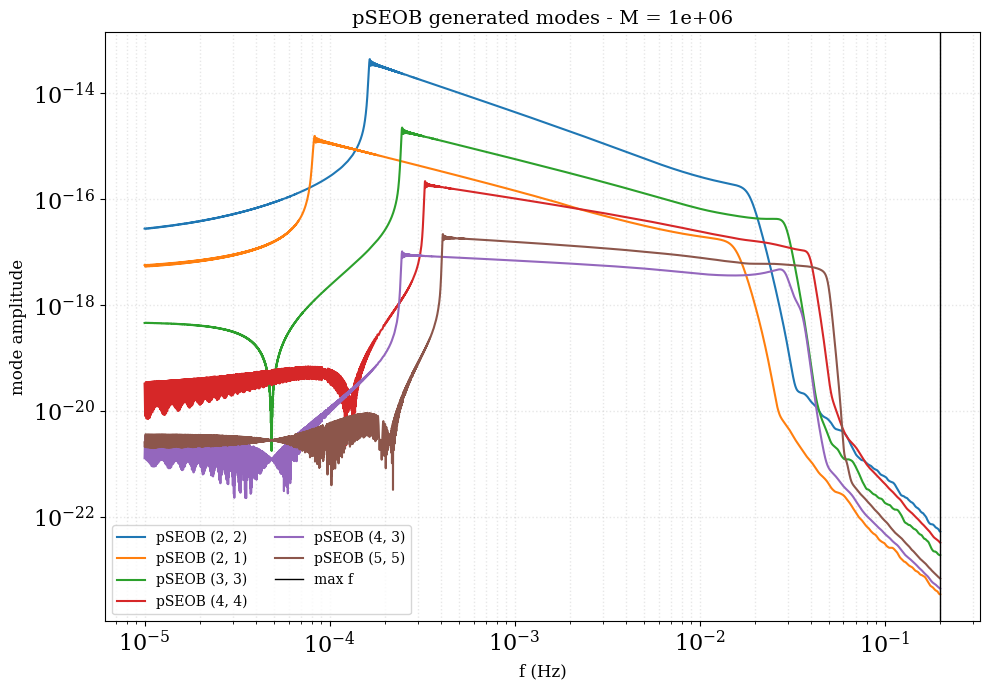

In [35]:
# Generating and plotting one pSEOB waveform directly.
params_plot = copy.deepcopy(params_base)
params_plot["M"] = 1e6

hlm_fd_plot = generate_pseob_fft(
    params_plot,
    modes=modes,
    waveform_params=waveform_params_base,
    verbose=True,
)

params_plot_ssb, wftdi_pseob = build_wftdi_from_hlm_fd(
    params_plot,
    hlm_fd_plot,
    modes=modes,
    t0=waveform_params_base["t0"],
)

fig, ax = plt.subplots(1, 1, figsize=[10, 7])

for lm in modes:
    if lm in wftdi_pseob:
        ax.loglog(
            wftdi_pseob[lm]["freq"],
            wftdi_pseob[lm]["amp"],
            linewidth=1.5,
            label=f"pSEOB {lm}"
        )

ax.axvline(waveform_params_base["maxf"], color="black", linestyle="-", linewidth=1, label="max f")
ax.set_xlabel("f (Hz)", fontsize=12)
ax.set_ylabel("mode amplitude", fontsize=12)
ax.set_title(f'pSEOB generated modes - M = {params_plot["M"]:.0e}', fontsize=14)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()


Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e6/datalm_pseob_M1e6_id_0.h5


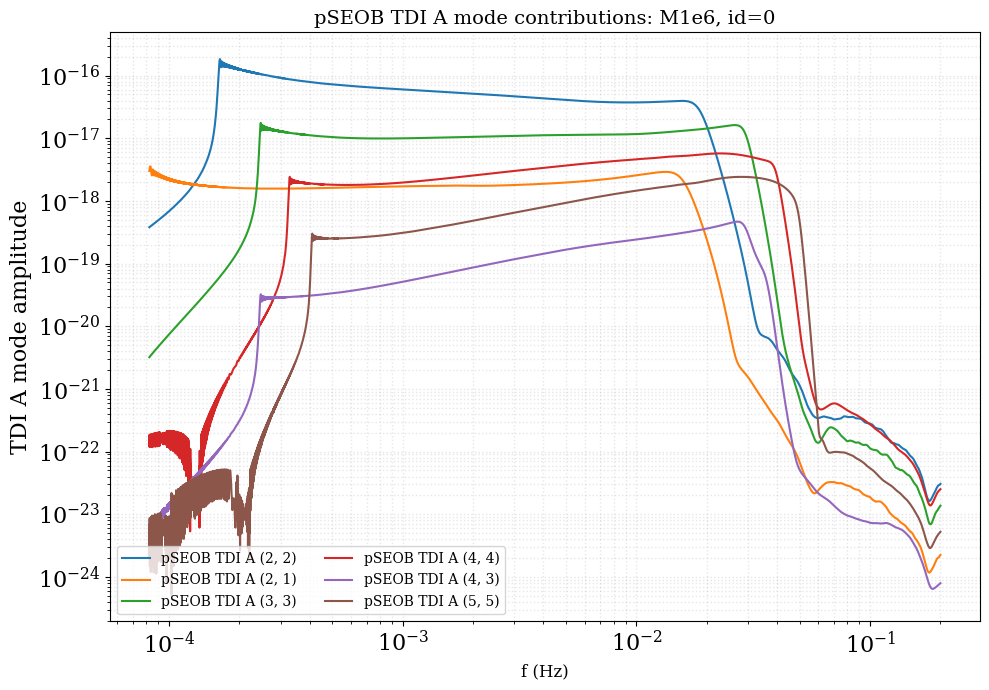

In [36]:
# Inspecting one generated mode-by-mode pSEOB TDI file.
iM = 1
im = 0
m_str = listM_str[iM]
datalm_path = os.path.join(Syst_dir, m_str, f'datalm_pseob_{m_str}_id_{im}.h5')

print('Reading:', datalm_path)

fig, ax = plt.subplots(1, 1, figsize=[10, 7])

with h5py.File(datalm_path, 'r') as hf:
    for lm in modes:
        group_name = f'h{lm[0]}{lm[1]}'
        if group_name in hf:
            f = hf[group_name]['freq'][:]
            amp_A = np.abs(hf[group_name]['TDIA'][:])
            ax.loglog(f, amp_A, linewidth=1.5, label=f'pSEOB TDI A {lm}')

ax.set_xlabel('f (Hz)', fontsize=12)
ax.set_ylabel('TDI A mode amplitude')
ax.set_title(f'pSEOB TDI A mode contributions: {m_str}, id={im}', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10, ncol=2, loc='lower left')
plt.tight_layout()
plt.show()


Reading: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e6/data_pseob_M1e6_id_0.h5
--- pSEOB generated TDI file ---
Keys: ['TDIA', 'TDIE', 'TDIT', 'freq']
Frequency grid size: 32723
Frequency range: 8.230e-05 to 2.000e-01 Hz


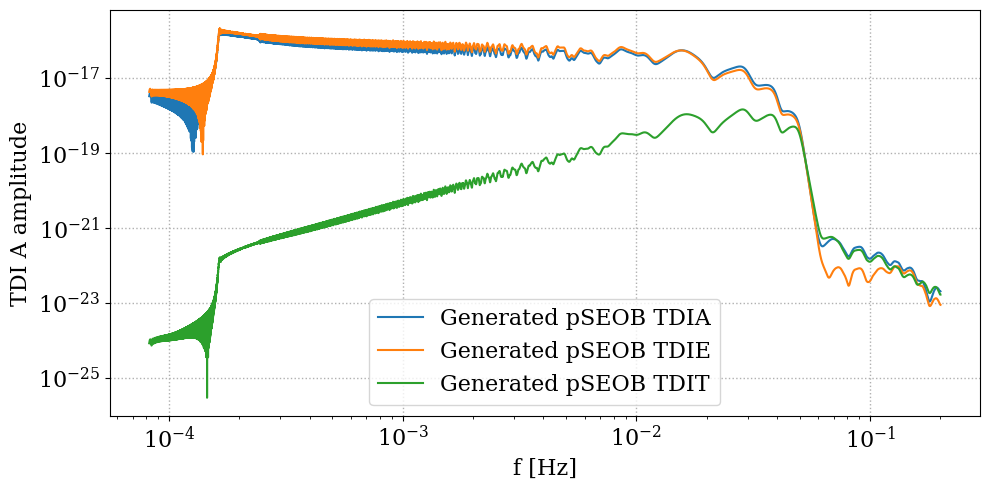

In [37]:
# Checking the datasets, frequency range, and channel amplitudes in one generated injection file.
m_str = 'M1e6'
im = 0
file_generated = os.path.join(Syst_dir, m_str, f'data_pseob_{m_str}_id_{im}.h5')

print('Reading:', file_generated)

def inspect_file(path):
    with h5py.File(path, 'r') as hf:
        data = {k: hf[k][:] for k in hf.keys()}
    return data

gen = inspect_file(file_generated)

print(f"--- pSEOB generated TDI file ---")
print(f"Keys: {list(gen.keys())}")
print(f"Frequency grid size: {len(gen['freq'])}")
print(f"Frequency range: {gen['freq'][0]:.3e} to {gen['freq'][-1]:.3e} Hz")

plt.figure(figsize=(10, 5))
for chan in ['TDIA', 'TDIE', 'TDIT']:
    if chan in gen:
        plt.loglog(gen['freq'], np.abs(gen[chan]), label=f'Generated pSEOB {chan}')
plt.xlabel('f [Hz]')
plt.ylabel('TDI A amplitude')
plt.legend()
plt.tight_layout()
plt.show()


Groups: ['h21', 'h22', 'h33', 'h43', 'h44', 'h55']


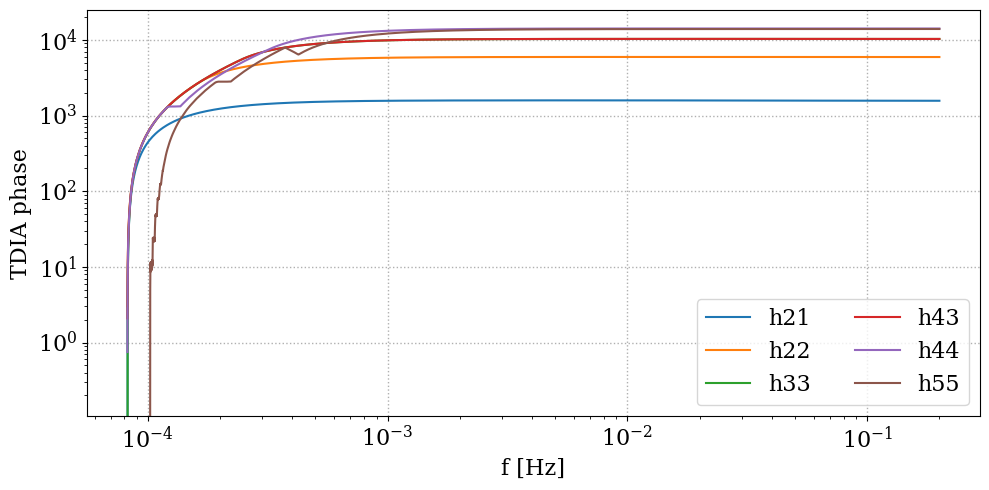

In [38]:
with h5py.File(datalm_file, "r") as hf:
    print("Groups:", list(hf.keys()))

    plt.figure(figsize=(10, 5))

    for group in hf.keys():
        f = hf[group]["freq"][:]
        A = hf[group]["TDIA"][:]
        plt.loglog(f, -np.unwrap(np.angle(A)), label=group)

    plt.xlabel("f [Hz]")
    plt.ylabel("TDIA phase")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()